In [2]:
import os
import pandas as pd
import csv
import matplotlib.pyplot as plt


In [3]:
# Get the directory with the notebooks, including its subdirectories
current_dir = os.getcwd()

# Get the directories with data and results
data_dir = os.path.join(current_dir, "data")
temporary_dir= os.path.join(current_dir, "temporary_data")
results_dir = os.path.join(current_dir, "results")

project_dir = os.path.dirname(current_dir)

inputs_dir = os.path.join(project_dir, "inputs")



In [4]:
# After we need to put together the PSYS and Size values for each program in each of the 3 different implementations

# Example usage
csv_with_ec = os.path.join(results_dir, 'averagePSYS_all_repeats.csv')
# Read the first CSV file
df = pd.read_csv(csv_with_ec, delimiter=';')
df


,Program,Utilities,PSYS
0,base64,BusyBox,4.303545e+05
1,base64,GNU,3.495048e+05
2,base64,ToyBox,9.077979e+05
3,basename,BusyBox,2.937127e+05
4,basename,GNU,2.940271e+05
...,...,...,...
79,true,GNU,2.947838e+05
80,true,ToyBox,2.908623e+05
81,wc,BusyBox,8.755721e+07
82,wc,GNU,4.546934e+08


In [5]:
# Note: The two following tables are in fact the used data 
# for Table 1 in the paper

df_pivot = df.pivot(index='Program', columns='Utilities')
df_pivot

PSYS                            
Utilities       BusyBox           GNU        ToyBox
Program                                            
base64     4.303545e+05  3.495048e+05  9.077979e+05
basename   2.937127e+05  2.940271e+05  2.926171e+05
cat        3.755542e+07  2.125736e+06  1.517433e+09
chmod      1.951976e+06  1.539669e+06  1.523403e+06
cksum      2.458047e+08  1.139345e+07  2.062460e+08
comm       1.208715e+08  5.506528e+07  3.383169e+08
cp         1.112494e+08  1.088484e+08  1.474435e+08
cut        4.932394e+06  2.207312e+06  1.139999e+07
date       3.122152e+05  3.153679e+05  3.153069e+05
dirname    3.100884e+05  3.215384e+05  3.122429e+05
du         4.905932e+05  5.232377e+05  5.185350e+05
echo       3.052972e+05  3.214469e+05  3.108848e+05
expand     1.456601e+07  7.273004e+06  5.023578e+05
factor     3.162590e+05  3.219719e+05  3.161642e+05
false      3.053183e+05  3.201407e+05  3.147483e+05
head       3.079398e+05  3.200187e+05  3.148215e+05
id         3.081933e+05  3.279167e+05  3.132042e+05
link       3.063437e+05  3.172843e+05  3.123558e+05
ln         3.051200e+05  3.224753e+05  3.357046e+05
logname    3.100822e+05  3.223869e+05  3.108298e+05
ls         8.980628e+05  1.048413e+06  3.487467e+06
md5sum     1.431506e+08  1.185998e+08  2.640305e+08
mkdir      2.976526e+05  3.066123e+05  3.003350e+05
mv         2.952782e+05  3.069390e+05  2.968988e+05
sort       3.182993e+08  9.554343e+07  4.693342e+08
touch      2.945090e+05  2.951958e+05  2.951806e+05
true       2.948539e+05  2.947838e+05  2.908623e+05
wc         8.755721e+07  4.546934e+08  1.514813e+08

In [6]:
# These are the DIFF.% values in Table 1 in the paper

df_pivot['Difference_BusyBox'] = ((df_pivot['PSYS']['BusyBox'] - df_pivot['PSYS']['GNU']) / df_pivot['PSYS']['GNU']) * 100
df_pivot['Difference_ToyBox'] = ((df_pivot['PSYS']['ToyBox'] - df_pivot['PSYS']['GNU']) / df_pivot['PSYS']['GNU']) * 100
new_df = pd.DataFrame({
                       'BusyBox': df_pivot['Difference_BusyBox'].round(2),
                       'ToyBox': df_pivot['Difference_ToyBox'].round(2)})
new_df

,BusyBox,ToyBox
Program,,
base64,23.13,159.74
basename,-0.11,-0.48
cat,1666.70,71283.90
chmod,26.78,-1.06
cksum,2057.42,1710.22
comm,119.51,514.39
cp,2.21,35.46
cut,123.46,416.46
date,-1.00,-0.02


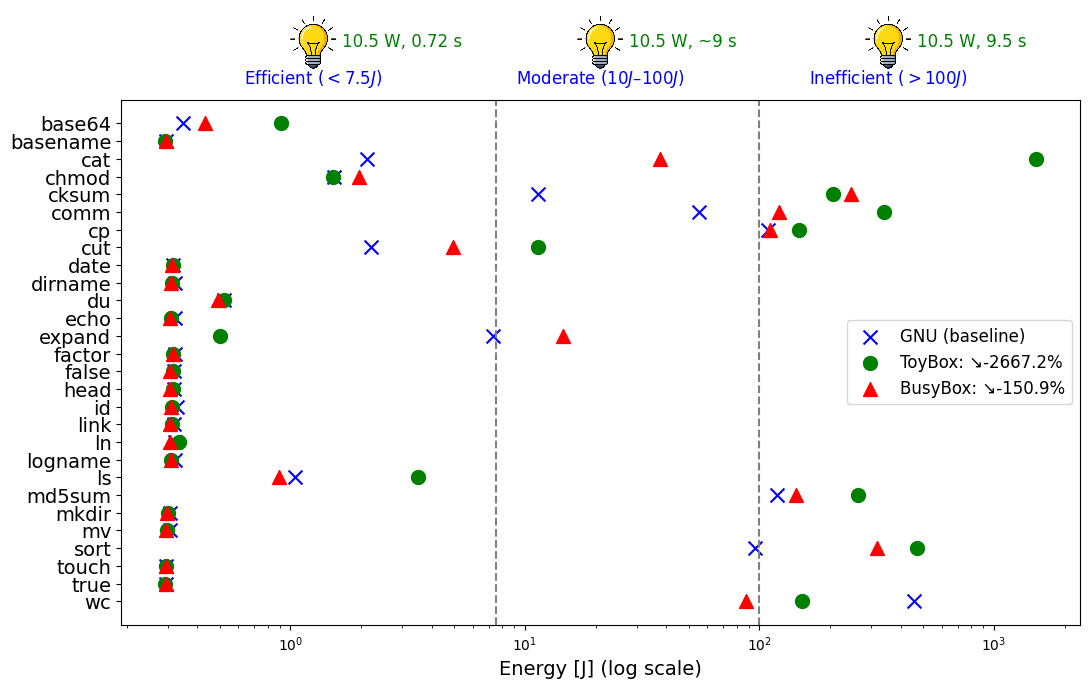

In [ ]:
# Dot-plot of per-program energy (log scale) with mean-reduction legends
import os
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# Load icon
bulb_img = plt.imread(os.path.join(current_dir, 'bulb.png'))

# Extract energy for each implementation
bb = df_pivot['PSYS']['BusyBox']
gnu = df_pivot['PSYS']['GNU']
tb  = df_pivot['PSYS']['ToyBox']

# Program order as original (invert_yaxis() will flip display)
programs = df_pivot.index

# Compute mean energy reductions vs GNU
toy_energy_red = (gnu - tb) / gnu * 100
bb_energy_red  = (gnu - bb) / gnu * 100
mean_toy_energy = toy_energy_red.mean()
mean_bb_energy  = bb_energy_red.mean()

# convert microjoules to joules for plotting
gnu_j = gnu / 1e6
tb_j  = tb  / 1e6
bb_j  = bb  / 1e6

fig, ax = plt.subplots(figsize=(11, 7))
# plot in joules
ax.scatter(gnu_j, programs, marker='x', color='blue',  s=100, label='GNU (baseline)')
ax.scatter(tb_j,  programs, marker='o', color='green', s=100, label=f'ToyBox: ↘{mean_toy_energy:.1f}%')
ax.scatter(bb_j,  programs, marker='^', color='red',   s=100, label=f'BusyBox: ↘{mean_bb_energy:.1f}%')

ax.set_xscale('log')
# vertical lines in joules
ax.axvline(7.5,  color='gray', linestyle='--')  # 7.5 J
ax.axvline(100,  color='gray', linestyle='--')  # 100 J

# place icons, keep labels at 1.02 and timing at 1.05
regions = [
    (0.2, 'Efficient ($< 7.5 J$)', '10.5 W, 0.72 s'),
    (0.5, 'Moderate ($10 J – 100 J$)', '10.5 W, ~9 s'),
    (0.8, 'Inefficient ($> 100 J$)', '10.5 W, 9.5 s')
]
for x, label, timing in regions:
    ab = AnnotationBbox(OffsetImage(bulb_img, zoom=0.05),
                       (x, 1.11), xycoords='axes fraction', frameon=False)
    ax.add_artist(ab)
    ax.text(x,       1.02, label,
            transform=ax.transAxes, ha='center', va='bottom',
            fontsize=12, color='gray')
    ax.text(x + 0.03, 1.11, timing,
            transform=ax.transAxes, ha='left', va='center',
            fontsize=12, color='green')

# Flip the y-axis so programs and points reverse order
ax.invert_yaxis()

# use LaTeX mu for micro-symbol in xlabel
ax.set_xlabel(r'Energy [J] (log scale)', fontsize=14)
ax.legend(fontsize=12)
ax.tick_params(axis='y', labelsize=14)
plt.tight_layout()
plt.show()

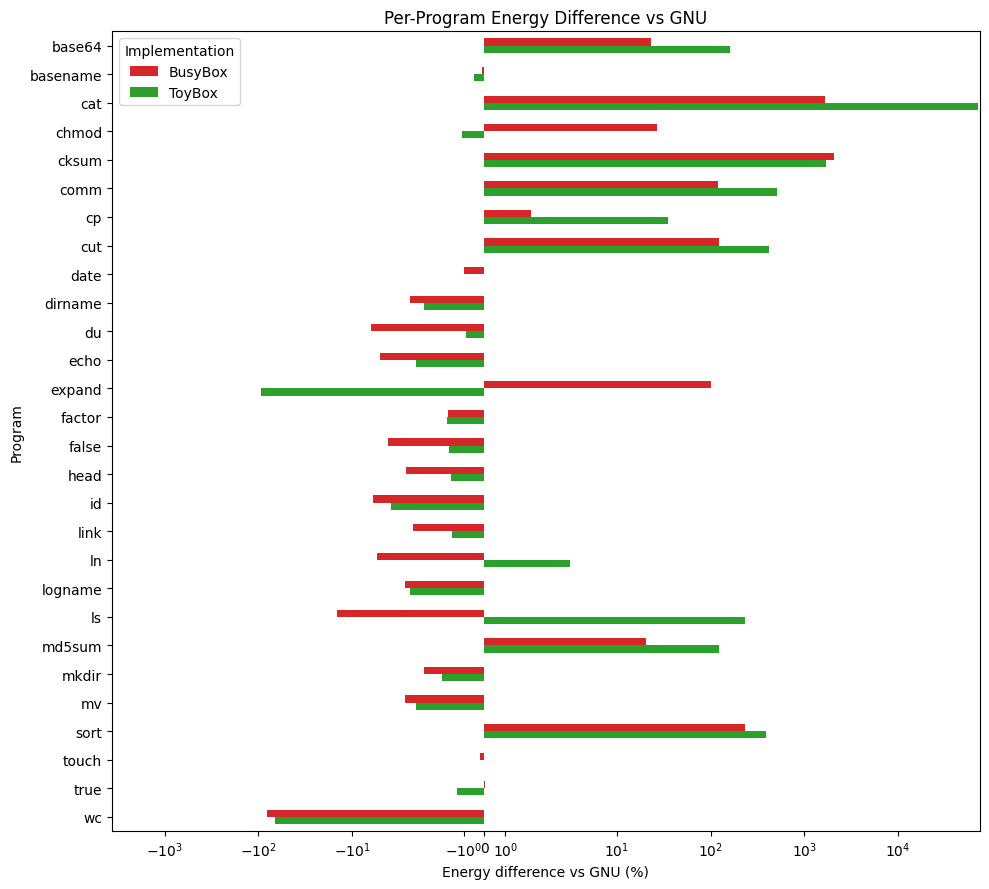

In [8]:
# Bar-plot of percent differences vs GNU (symlog scale)
import matplotlib.pyplot as plt

# new_df contains 'BusyBox' and 'ToyBox' diff percentages

fig, ax = plt.subplots(figsize=(10, 9))
new_df.plot(kind='barh', ax=ax, color=['#d62728', '#2ca02c'], legend=True)
# apply symmetric log scale with linear threshold around small values
ax.set_xscale('symlog', linthresh=5)
ax.set_xlabel('Energy difference vs GNU (%)')
ax.set_title('Per-Program Energy Difference vs GNU')
ax.legend(title='Implementation')
ax.invert_yaxis()  # keep program order top→bottom
plt.tight_layout()
plt.show()